In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [8]:
df = pd.read_csv('clean_streetlight_dataset (2).csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Extract hour feature from timestamp
df['hour'] = df['timestamp'].dt.hour

df.head()

/var/folders/fb/mzvs3bqx7xvg0nr49pzb0_9m0000gn/T/ipykernel_92177/2311957798.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


,timestamp,power_consumption (Watts),voltage_levels (Volts),current_fluctuations (Amperes),temperature (Celsius),environmental_conditions,current_fluctuations_env (Amperes),fault_type,hour
20691,2026-03-12 00:00:00,114.00,232.71,1.35,28.32,2,4.61,0,0
19281,2026-03-12 00:00:01,123.88,232.59,0.08,25.11,1,0.47,0,0
11101,2026-03-12 00:00:01,89.11,221.57,1.54,22.30,1,0.77,0,0
13794,2026-03-12 00:00:02,58.61,226.17,3.41,28.92,1,0.71,0,0
14219,2026-03-12 00:00:05,68.95,231.69,0.40,15.17,1,1.80,0,0


In [9]:
rf_model = joblib.load('random_forest_model.pkl')
log_model = joblib.load('logistic_regression_model.pkl')
dt_model = joblib.load('decision_tree_model.pkl')

In [10]:
# Encode categorical column (same as in model training notebooks)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['environmental_conditions'] = le.fit_transform(df['environmental_conditions'])

# Drop timestamp (not used in model training)
X = df.drop(['fault_type','timestamp'], axis=1)
y = df['fault_type']

In [11]:
df['rf_pred'] = rf_model.predict(X)
df['log_pred'] = log_model.predict(X)
df['dt_pred'] = dt_model.predict(X)

df[['rf_pred','log_pred','dt_pred']].head()

,rf_pred,log_pred,dt_pred
20691,0,0,0.0
19281,0,0,0.0
11101,0,0,0.0
13794,0,0,0.0
14219,0,0,0.0


In [12]:
def calculate_mttd(data, pred_col):
    faults = data[data['fault_type']==1]
    delays = []
    
    for fault_time in faults['timestamp']:
        detection = data[(data['timestamp'] >= fault_time) & (data[pred_col]==1)]
        
        if not detection.empty:
            detect_time = detection.iloc[0]['timestamp']
            delay = (detect_time - fault_time).total_seconds()
            delays.append(delay)
    
    return np.mean(delays) if delays else None

In [13]:
rf_mttd = calculate_mttd(df, 'rf_pred')
log_mttd = calculate_mttd(df, 'log_pred')
dt_mttd = calculate_mttd(df, 'dt_pred')

print('Random Forest MTTD:', rf_mttd)
print('Logistic Regression MTTD:', log_mttd)
print('Decision Tree MTTD:', dt_mttd)

Random Forest MTTD: 0.0
Logistic Regression MTTD: 2.4859320046893316
Decision Tree MTTD: 0.0


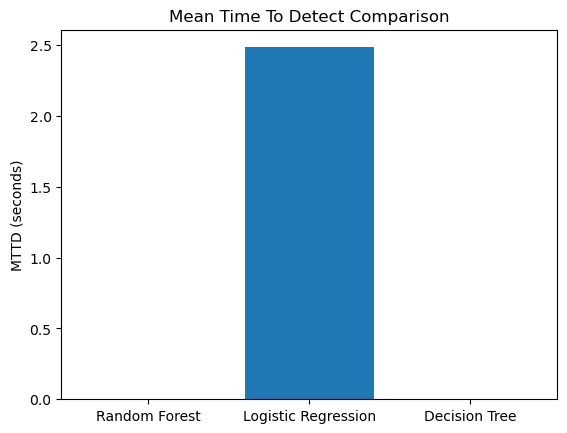

In [14]:
models = ['Random Forest','Logistic Regression','Decision Tree']
mttd_values = [rf_mttd, log_mttd, dt_mttd]

plt.figure()
plt.bar(models, mttd_values)
plt.ylabel('MTTD (seconds)')
plt.title('Mean Time To Detect Comparison')
plt.show()

In [15]:
polling_intervals = [5,10,15,30,60]
detection_delay = [p/2 for p in polling_intervals]

polling_df = pd.DataFrame({
    'Polling Interval (sec)': polling_intervals,
    'Expected Detection Delay (sec)': detection_delay
})

polling_df

,Polling Interval (sec),Expected Detection Delay (sec)
0,5,2.5
1,10,5.0
2,15,7.5
3,30,15.0
4,60,30.0


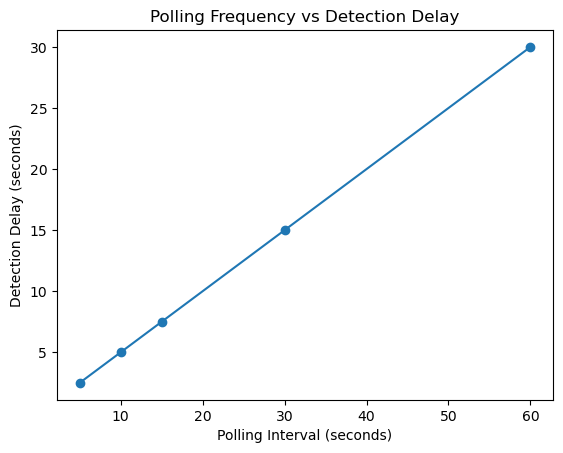

In [16]:
plt.figure()
plt.plot(polling_intervals, detection_delay, marker='o')
plt.xlabel('Polling Interval (seconds)')
plt.ylabel('Detection Delay (seconds)')
plt.title('Polling Frequency vs Detection Delay')
plt.show()